<a href="https://colab.research.google.com/github/iestleija/4808-Programacion/blob/Unidad2/Unidad2/Practices/Practica20_266229.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,**Maestría en Inteligencia Artificial y Analítica de Datos**

- Curso: Programación para Analítica Descriptiva y Predictiva

- Semestre: Enero-Junio

- Profesor: Dr. Vicente García Jiménez
- Práctica:
Práctica #20: Análisis Exploratorio de Datos (EDA)
- Alumno: Ismael Estrada Leija
- Matrícula: 266229

# Instrucciones de la tarea: Análisis Exploratorio de Datos (EDA)

**Objetivo**

Realizar un **Análisis Exploratorio de Datos (EDA)** aplicando técnicas estadísticas y de visualización para comprender la estructura, distribución y relaciones dentro de un conjunto de datos.

Utiliza el archivo `AirQuality` que se proprociona

### Entregable
Debes entregar: un archivo de txt con el link a tu cuaderno (con permisos de visualización) o repositorio en github


## Entorno de trabajo

La actividad **debe realizarse obligatoriamente en Google Colab**.

El notebook debe incluir:

- código en Python

- visualizaciones

- celdas de texto con interpretación de los resultados

Cada sección del análisis debe estar **claramente documentada**



In [44]:
# Google drive mounting
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:

# Environment set up
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;
import math


def print_bold(msg):
    print("\n\033[1m" + msg + "\033[0m");
file_path = '/content/drive/MyDrive/4808-programacion/U02/P20/AirQuality.csv';
all_ok  = True; # Goes false on any failure
numeric_columns = ['CO(GT)','PT08.S1(CO)','NMHC(GT)','C6H6(GT)','PT08.S2(NMHC)','NOx(GT)','PT08.S3(NOx)','NO2(GT)','PT08.S4(NO2)','PT08.S5(O3)','T','RH','AH'];
numerical_sample_cols = ['NMHC(GT)','C6H6(GT)','PT08.S2(NMHC)']
categorical_sample_cols = ['Time']

## Estructura que debe tener el Google Colab
El notebook deberá estar organizado en las siguientes secciones.



# 1. Introducción del dataset
Incluye una sección donde expliques:

- Nombre del dataset

- Fuente de donde fue obtenido

- Número de observaciones

- Número de variables

- Descripción de las variables

También debes mostrar:

- las primeras filas del dataset (`head()`)

- la estructura del dataset (`info()`)

## Air Quality Dataset
Se han cargado los datos desde el archivo `AirQuality.csv` y la siguiente es la estructura inicial.
- **Dataset:** Air Quality
- **Fuente:** Campus Virtual de la UACJ
- **Número de observaciones:** 9,471
- **Número de variables:** 17

In [82]:
# Data loading into dataframe
try:
  air_q_df = pd.read_csv(file_path, delimiter=';');
  print_bold("Dataset cargado correctamente desde el archivo AirQuality.csv\n");
  print(f"Uso de memoria: {air_q_df.memory_usage(deep=True).sum()/1024:.1f} KB")
  all_ok = True;
except:
  print("Error al cargar el archivo AirQuality");
  all_ok = False;


Dataset cargado correctamente desde el archivo AirQuality.csv

Uso de memoria: 4249.5 KB


### Comprensión Inicial del Conjunto de Datos
El conjunto de datos en análisis fue proporcionado en el campus virtual de la Universidad Autónoma de Ciudad Juárez, como un archivo con formato csv y su nombre es AirQuality.csv

Es muy similar al dataset Air Quality existente en el repositorio `UC Irvine Machine Learning Repository` que se puede acceder en el enlace siguiente.
https://archive.ics.uci.edu/dataset/360/air+quality


#### ¿Cuántas filas y columnas tiene el dataset?
La propiedad `shape` del dataframe nos permite visualizar cuantas filas y columnas conforman dicho dataframe.

In [83]:
if all_ok:
  print_bold("Tamaño del dataset (Filas, Columnas)");
  print(air_q_df.shape);


Tamaño del dataset (Filas, Columnas)
(9471, 17)


#### ¿Qué tipo de dato tiene cada variable?
La función `info` de `pandas` nos muestra las columnas del dataframe con el conteo de nulos y tipo de datos. Vemos la siguiente estructura:
- 7 columnas de tipo object
- 10 columnas de tipo flotante
- Exceptuando la fecha y hora, los valores reportados en el repositorio UCI son descritos como lecturas de sensores o promedios de las mismas; por tanto, debieran ser numéricas. Por su parte Date debiera ser datetime y time por sus pocos valores pudiera convertirse a categoría para efectos de práctica.

In [84]:
if all_ok:
  print_bold(f"Time tiene solo [{air_q_df["Time"].nunique()}] valores únicos");
  print_bold("Columnas del dataset con su conteo de nulos y tipo de datos\n");
  print(air_q_df.dtypes);




Time tiene solo [24] valores únicos

Columnas del dataset con su conteo de nulos y tipo de datos

Date              object
Time              object
CO(GT)            object
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)          object
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                 object
RH                object
AH                object
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object


As reference only, according to the table below coming from the UCI there are
- 6 categorical variables,
- 8 numerical variables (4 integer and  4 continuous)
- 1 Date variable
- 2 Two columns depicted by the pandas dtypes are not reported here

| Variable Name | Role    | Type        | Units      | Missing Values | Description                                                                                            |
|---------------|---------|-------------|------------|----------------|--------------------------------------------------------------------------------------------------------|
| Date          | Feature | Date        |            | no             |                                                                                                        |
| Time          | Feature | Categorical |            | no             |                                                                                                        |
| CO(GT)        | Feature | Integer     | mg/m^3     | no             | True hourly averaged concentration CO in mg/m^3 (reference analyzer)                                   |
| PT08.S1(CO)   | Feature | Categorical |            | no             | hourly averaged sensor response (nominally CO targeted)                                                |
| NMHC(GT)      | Feature | Integer     | microg/m^3 | no             | True hourly averaged overall Non Metanic HydroCarbons concentration in microg/m^3 (reference analyzer) |
| C6H6(GT)      | Feature | Continuous  | microg/m^3 | no             | True hourly averaged Benzene concentration in microg/m^3 (reference analyzer)                          |
| PT08.S2(NMHC) | Feature | Categorical |            | no             | hourly averaged sensor response (nominally NMHC targeted)                                              |
| NOx(GT)       | Feature | Integer     | ppb        | no             | True hourly averaged NOx concentration in ppb (reference analyzer)                                     |
| PT08.S3(NOx)  | Feature | Categorical |            | no             | hourly averaged sensor response (nominally NOx targeted)                                               |
| NO2(GT)       | Feature | Integer     | microg/m^3 | no             | True hourly averaged NO2 concentration in microg/m^3 (reference analyzer)                              |
| PT08.S4(NO2)  | Feature | Categorical |            | no             | hourly averaged sensor response (nominally NO2 targeted)                                               |
| PT08.S5(O3)   | Feature | Categorical |            | no             | hourly averaged sensor response (nominally O3 targeted)                                                |
| T             | Feature | Continuous  | °C         | no             | Temperature                                                                                            |
| RH            | Feature | Continuous  | %          | no             | Relative Humidity                                                                                      |
| AH            | Feature | Continuous  |            | no             | Absolute Humidity                                                                                      |



#### ¿Existen valores nulos o faltantes?
Conteo inicial de faltantes:
- Hay 114 valores faltantes en las primeras 15 columnas
- Las últimas dos columnas estan vacías

In [85]:
print_bold("Conteo de valores nulos")
print(air_q_df.isnull().sum())

pct = (air_q_df.isnull().mean() * 100).round(2)
print_bold("Porcentaje de valores nulos")

print(pct)


Conteo de valores nulos
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

Porcentaje de valores nulos
Date               1.2
Time               1.2
CO(GT)             1.2
PT08.S1(CO)        1.2
NMHC(GT)           1.2
C6H6(GT)           1.2
PT08.S2(NMHC)      1.2
NOx(GT)            1.2
PT08.S3(NOx)       1.2
NO2(GT)            1.2
PT08.S4(NO2)       1.2
PT08.S5(O3)        1.2
T                  1.2
RH                 1.2
AH                 1.2
Unnamed: 15      100.0
Unnamed: 16      100.0
dtype: float64


#### ¿Existen valores nulos o faltantes?
#### Filas vacías
El conteo de no nulos nos muestra que algunas columnas tienen datos en 9357/9471.
Con la función `isna` de pandas identificamos las filas que tienen solo valores nulos en todas sus columnas, resultando en las últimas 114 filas, del índice 9357 al 9470, asi se muestra en la celda siguiente de este documento.

In [86]:
print_bold("Identificación de filas vacías\n")
air_q_df[air_q_df.isna().all(axis=1)]



Identificación de filas vacías



,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### ¿Existen valores nulos o faltantes?
El repositorio UCI establece que los valores faltantes estan etiquetados con el valor -200: "Missing values are tagged with -200 value."

La búsqueda siguiente revela provisionalmente, por la existencia de comas en algunos datos numéricos,  que hay 8506 filas con el valor centinela.

In [87]:
missing_value_flag = -200.0

# filtering rows with null flag.
absent_value_rows = air_q_df[(air_q_df[numeric_columns] == missing_value_flag).any(axis=1)]
absent_value_rows


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9,11/03/2004,03.00.00,"0,6",1010.0,19.0,"1,7",561.0,-200.0,1705.0,-200.0,1235.0,501.0,"10,3","60,2","0,7517",NaN,NaN
33,12/03/2004,03.00.00,"0,8",889.0,21.0,"1,9",574.0,-200.0,1680.0,-200.0,1187.0,512.0,"7,0","62,3","0,6261",NaN,NaN
39,12/03/2004,09.00.00,-200,1545.0,-200.0,"22,1",1353.0,-200.0,767.0,-200.0,2058.0,1588.0,"9,2","56,2","0,6561",NaN,NaN
57,13/03/2004,03.00.00,"1,7",1172.0,46.0,"5,4",783.0,-200.0,1179.0,-200.0,1380.0,996.0,"7,8","67,5","0,7173",NaN,NaN
81,14/03/2004,03.00.00,"2,4",1344.0,132.0,"9,7",968.0,-200.0,921.0,-200.0,1620.0,1278.0,"11,6","63,4","0,8674",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,"3,1",1314.0,-200.0,"13,5",1101.0,472.0,539.0,190.0,1374.0,1729.0,"21,9","29,3","0,7568",NaN,NaN
9353,04/04/2005,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119",NaN,NaN
9354,04/04/2005,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406",NaN,NaN
9355,04/04/2005,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139",NaN,NaN


####¿Existen duplicados o inconsistencias en los datos?
- Se reportan 114 filas duplicadas que coinciden con el número de filas vacías.
- Hay columnas con puntuación numérica europea que usan coma para separar los decimales.

In [88]:
print_bold(f"Filas duplicadas:{air_q_df.duplicated(keep=False).sum()}")

print_bold("Muestra del contenido del dataset\n")
air_q_df


Filas duplicadas:114

Muestra del contenido del dataset



,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


####¿Cuál es el rango y la distribución de las variables numéricas?
Debido al estado actual de los datos esa pregunta quedará pendiente para después del preprocesamiento del conjunto de datos. Por el momento no aparecen todas las variables numéricas y los estadísticos se ven alterados por los valores centinela para datos ausentes.

####¿Cuál es la distribución de las variables categóricas?
Falta determinar que variables son realmente categóricas, porque exceptúando dos todas son numéricas que provienen de lecturas de sensores.

### Limpieza de los datos.
En esta sección se realizan algunas tareas de preparación y limpieza de los datos


#### Paso 1: En esta operación las comas se remplazan por puntos.

In [89]:

cleaned_df_step1 = air_q_df.copy()


# replacing decimal separator from comma to dot
cleaned_df_step1[numeric_columns] = cleaned_df_step1[numeric_columns].replace(',', '.', regex=True).astype(float);
cleaned_df_step1

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Paso 2: Eliminacion de columnas y filas vacías
Una vez eliminadas las columnas y filas vacías al conjunto de datos solo le falta una fila para tener la misma forma que el conjunto de datos del repositorio UCI referenciado antes.


In [90]:
#Eliminación de columnas que solo contienen nulos
cleaned_df_step2 = cleaned_df_step1.dropna(axis=0, how='all')

#Eliminación de filas que solo contienen nulos
cleaned_df_step2 = cleaned_df_step2.dropna(axis=1, how='all').reset_index(drop=True)
cleaned_df_step2

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139



####Paso 3: Remplazo de valor centinela de valores nulos
Dado que el valor centinela afecta los estadísticos de las diversas variables lo remplazaremos con `np.nan`. Con lo anterior eliminamos el efecto del valor centinela. Se muestra como los estadísticos no muestran mas el valor centinela y sus valores han cambiado.

*Esta decisión permite continuar con el procesamiento del dataset, pero no ha sido autorizada por el usuario del dataset.*

In [91]:
missing_value_flag = -200
cleaned_df_step3 = cleaned_df_step2.copy();

# replacing null flag (-200.0) with np.nan
cleaned_df_step3[numeric_columns] = cleaned_df_step3[numeric_columns].replace(missing_value_flag, np.nan)
cleaned_df_step3.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


####Paso 4: Convertir los datos de  fecha y tiempo
Los datos de fecha y tiempo que vienen como texto se convierten a tipos de datos manejables por pandas, para facilitar su procesamiento.

*Para efectos de práctica la columna type es asignada con el tipo de datos `category`*

In [92]:
cleaned_df_step4 = cleaned_df_step3.copy();

# datetime data type applied to columnc Date
cleaned_df_step4['Date'] = pd.to_datetime(cleaned_df_step4['Date'], format='%d/%m/%Y', errors='coerce')

# Convert time column into a categorical variable.
cleaned_df_step4['Time'] = cleaned_df_step4['Time'].astype('category')

# 2.  Exploración inicial de datos
Realiza lo siguiente:

- Identificar valores faltantes
- Analizar tipos de variables
- Revisar posibles valores atípicos
- Mostrar estadísticas descriptivas básicas (describe())

Explica brevemente lo que observas.

---
Realizaremos ahora la exploración sobre el dataframe que ha sido limpiado.

####Identificar valores faltantes
Se identifican valores faltantes con el uso de `df.isnull()`
Existen 9 variables que carecen de exactamente 366 valores; si son coincidentes en las mismas observaciones, esas observaciones pudieran descartarse. Otras tres variables carecen de poco mas de alrededor de 1650 valores y una de ellas, NMHC(GT) alcanza apenas el 10% de valores válidos en el conjunto de datos.

In [93]:
cleaned_air_q_df = cleaned_df_step4.copy();
print_bold("Conteo de valores nulos")
print(cleaned_air_q_df.isnull().sum())

pct = (cleaned_air_q_df.isnull().mean() * 100).round(2)
print_bold("Porcentaje de valores nulos")

print(pct)


Conteo de valores nulos
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Porcentaje de valores nulos
Date              0.00
Time              0.00
CO(GT)           17.99
PT08.S1(CO)       3.91
NMHC(GT)         90.23
C6H6(GT)          3.91
PT08.S2(NMHC)     3.91
NOx(GT)          17.52
PT08.S3(NOx)      3.91
NO2(GT)          17.55
PT08.S4(NO2)      3.91
PT08.S5(O3)       3.91
T                 3.91
RH                3.91
AH                3.91
dtype: float64


####Analizar tipos de variables.
La estructura del dataset cuenta ahora con:
- Una variable `datetime`
- Una variable categórica
- 13 variables numéricas de tipo flotante

In [94]:
cleaned_air_q_df.dtypes

,0
Date,datetime64[ns]
Time,category
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


#### Revisar posibles valores atípicos
Revisamos valores atípicos con el uso de la distancia en base al IQR (Inter-Quartile Range) conforme a la nota de (Bruce et al., 2020) con respecto al diseño de los boxplots: *By default, the R function extends the whiskers to the furthest point beyond the box, except that it will not go beyond 1.5 times the IQR. Matplotlib uses the same implementation; other software may use a different rule.*



In [95]:
# Analizando una sola variable.
outliers_sample_column = 'NMHC(GT)';

# Calculamos los cuartiles Q1 (25%) y Q3 (75%)
Q1 = cleaned_air_q_df[outliers_sample_column].quantile(0.25)
Q3 = cleaned_air_q_df[outliers_sample_column].quantile(0.75)

# Calculamos el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# Definimos los límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificamos los outliers
outliers = cleaned_air_q_df[(cleaned_air_q_df[outliers_sample_column] < limite_inferior) | (cleaned_air_q_df[outliers_sample_column] > limite_superior)]

print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")
print(f"Número de outliers detectados para {outliers_sample_column}: {(outliers.shape[0])}")


Límite inferior: -278.0
Límite superior: 642.0
Número de outliers detectados para NMHC(GT): 55


#### Revisar posibles valores atípicos
Identificación gráfica de valores atípicos, se observa que todos ellos son valores de la parte superior del rango.

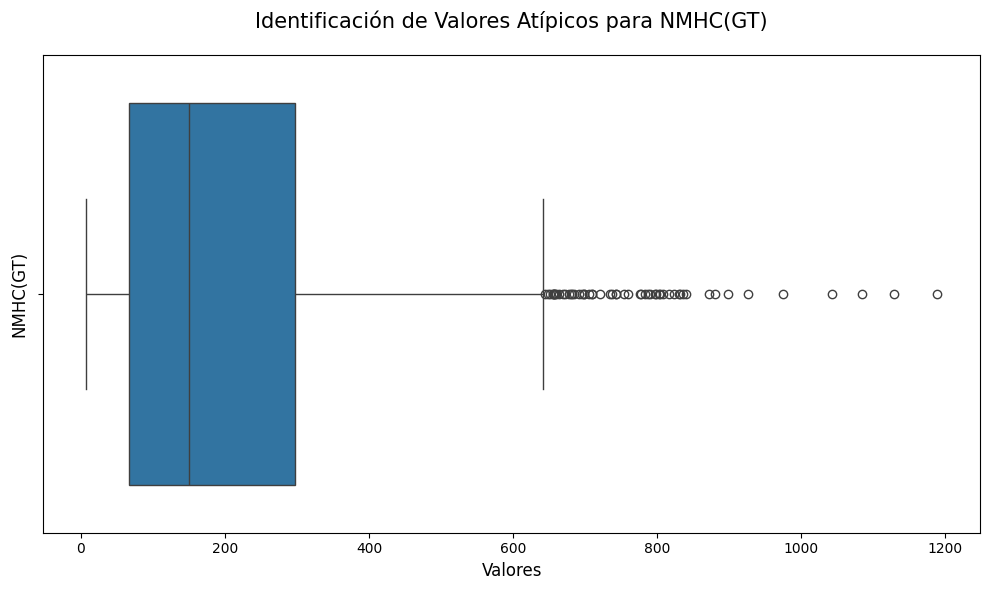

In [96]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=cleaned_air_q_df[outliers_sample_column])
plt.title(f'Identificación de Valores Atípicos para {outliers_sample_column}', fontsize=15, pad=20)
plt.ylabel(outliers_sample_column, fontsize=12)
plt.xlabel('Valores', fontsize=12)

plt.tight_layout()
plt.show()

#### Mostrar estadísticas descriptivas básicas (describe())
La siguiente es la descripción estadística de las variables numéricas del dataframe. Tenemos una descripción con las principales medidas de distribución estadística. Todos son valores, sujetos a la condición de que el conteo para algunas de las variables es muy bajo.

In [97]:
cleaned_air_q_df[numeric_columns].describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


# 3. Análisis univariado
Analiza **una variable** individualmente.

Para **variables numéricas**, elige algunas de las siguientes herramientas:

- histogramas + KDE

- boxplot

Para **variables categóricas**, si existe, elige una de ellas incluye una de las siguientes herramientas (elige la que quieras):

- gráficas de barras

- gráficas de pastel

En cada gráfico debes interpretar brevemente los resultados.

####Variables numéricas


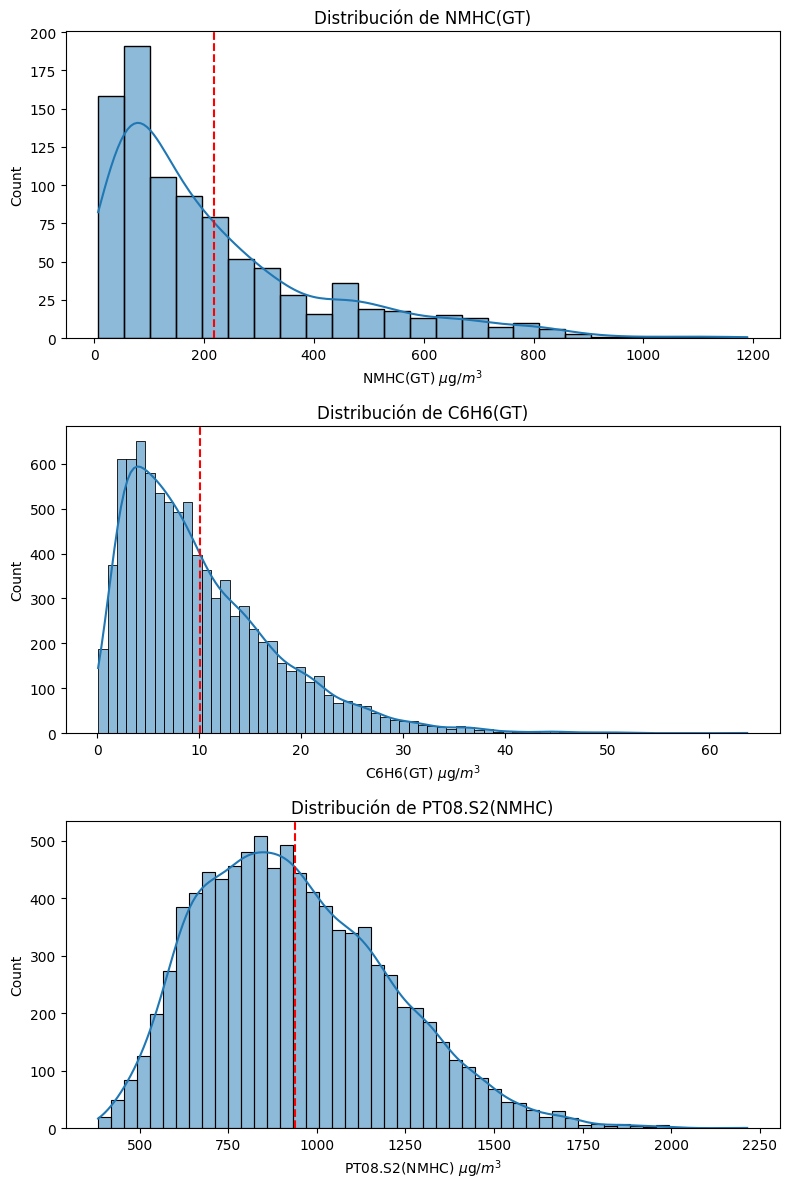

In [98]:


# crear subplots
fig, axes = plt.subplots(len(numerical_sample_cols), 1, figsize=(8, 4*len(numerical_sample_cols)))

# generar histogramas
for i, col in enumerate(numerical_sample_cols):
    sns.histplot(cleaned_air_q_df[col], ax=axes[i], kde=True)
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(f"{col} $\\mu$g/$m^3$")
    axes[i].axvline(cleaned_air_q_df[col].mean(), color='red', linestyle='--', label='Media')

plt.tight_layout()
plt.show()


####Interpretación de Histogramas

Se muestran los histogramas para tres variables, dos de referencia y una de los sensores en estudio para su calibración.

 - Hidrocarburos no metánicos [NMHC(GT)]: Del analizador de referencia, tiene una media cercana a $218 \mu g / m^3$ y muestra una distribución sesgada positivamente con una alta concentración por debajo de $200 \mu g/ m^3$ y una larga cola de valores hacia la derecha, decreciendo en cantidad y alcanzando los $1200 \mu g/ m^3$
 - Benzeno [C6H6(GT)]:  Del analizador de referencia, partiendo de un pormedio de $10 \mu g / m^3$, cuenta con una distribución muy similar en forma a la anterior, con un sesgo positivo y alta concentracion de valores por debajo de $10 \mu g/m^3$ y una cola larga hacia la derecha que casi desaparece a los $40 \mu g/m^3$ pero se extiende hasta alcanzar atípicamente los $65 \mu g / m^3$
 - Hidrocarburos no metánicos [PT08.S2(NMHC)]:  Del sensor evaluado, muestra una distribución mas uniforme que las anteriores con una media de aproximádamente $940 \mu g / m^3$, un sesgo positivo ligero y valores atípicos que se extienden a la derecha hasta valores cercanos a los $2200 \mu g / m^3$


####Variable categórica
Se usa Time como variable categórica para efectos de práctica.

<Figure size 1000x600 with 0 Axes>

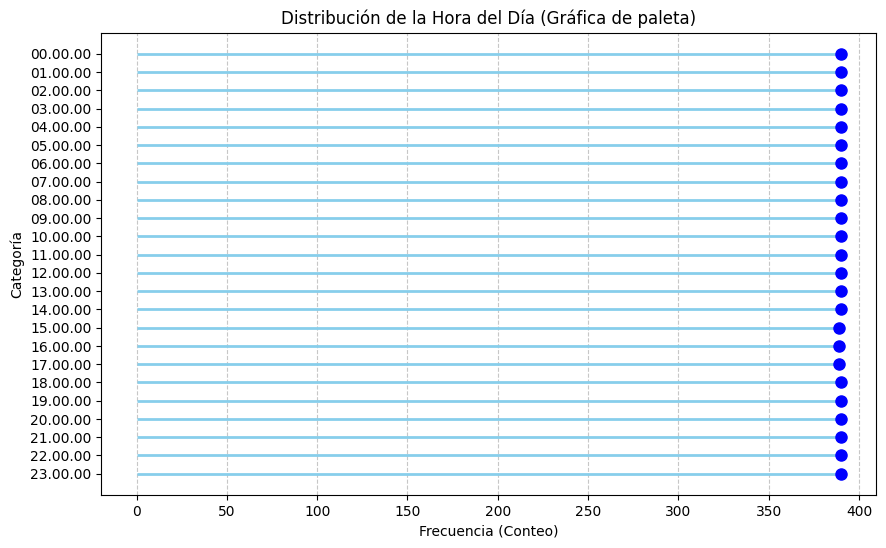

<Figure size 640x480 with 0 Axes>

In [99]:
# Gráfica de paleta usando pyplot

plt.figure(figsize=(10,6));

# Obtener los conteos de la columna categórica
counts = cleaned_air_q_df['Time'].value_counts().sort_index(ascending=False);

# Crear el gráfico
plt.figure(figsize=(10, 6));

# Dibujar las líneas horizontales (desde el origen 0 hasta el valor de la frecuencia)
plt.hlines(y=counts.index, xmin=0, xmax=counts.values, color='skyblue', linewidth=2);

# Dibujar los puntos en las puntas
plt.plot(counts.values, counts.index, "o", markersize=8, color='blue');

# Configuración visual
plt.xlabel('Frecuencia (Conteo)');
plt.ylabel('Categoría');
plt.title('Distribución de la Hora del Día (Gráfica de paleta)');
plt.grid(axis='x', linestyle='--', alpha=0.7); # Guía visual opcional
plt.show();
plt.tight_layout();



# 4. Análisis bivariado
Analiza relaciones entre dos variables. Elige las variables que gustes

**Numérica vs Numérica**

Utiliza:

- scatter plots

Explica qué relaciones observas.

####Análisis Bivariado: Numérica/Numérica
La gráfica de dispersión muestra una relación positiva entre los valores que toman los registros de concentración de benceno (C6H6(GT)) y los de Monóxido de Carbono  (CO(GT)). Con cierta variabilidad tienen un crecimiento similar, considerando que usan distintas unidades de medida.

Pearson  r = 0.931  (p=0.0000)
Spearman ρ = 0.927  (p=0.0000)
Diferencia = 0.004
→ Relación aproximadamente lineal, reporta Pearson


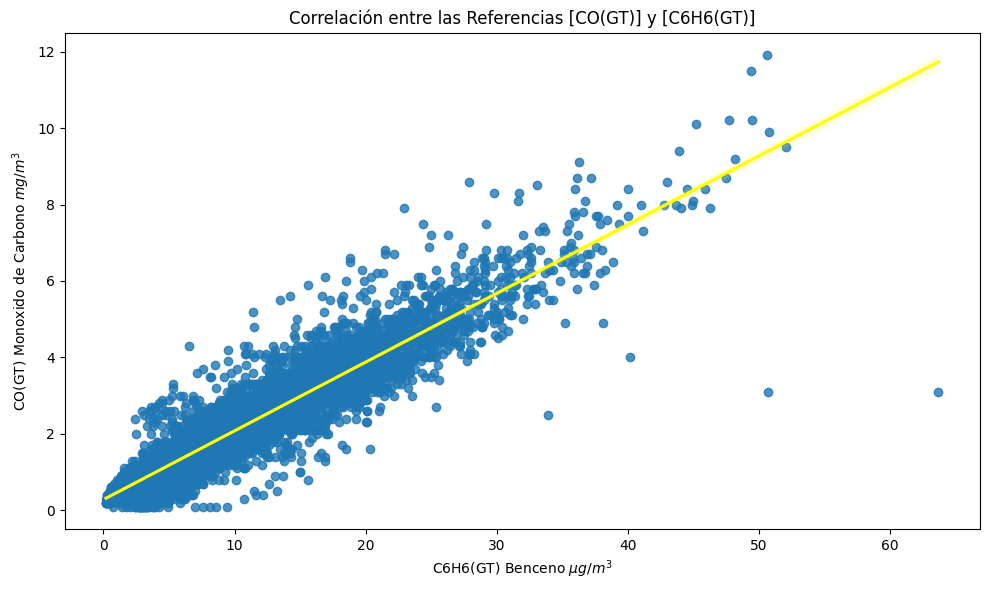

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

plt.figure(figsize=(10, 6))
sns.regplot(data=cleaned_air_q_df, x="C6H6(GT)", y="CO(GT)",  line_kws={"color": "yellow"})
plt.title('Correlación entre las Referencias [CO(GT)] y [C6H6(GT)]')
plt.xlabel('C6H6(GT) Benceno $\\mu g /m^3$')
plt.ylabel('CO(GT) Monoxido de Carbono $mg/m^3$')

plt.tight_layout()

# Preparar los datos eliminando los NaNs para las columnas específicas
data_for_correlation = cleaned_air_q_df[['C6H6(GT)', 'CO(GT)']].dropna()

# Paso 2: calcular ambos
r_p, p_p = pearsonr(data_for_correlation['C6H6(GT)'], data_for_correlation['CO(GT)'])
r_s, p_s = spearmanr(data_for_correlation['C6H6(GT)'], data_for_correlation['CO(GT)'])

print(f"Pearson  r = {r_p:.3f}  (p={p_p:.4f})")
print(f"Spearman ρ = {r_s:.3f}  (p={p_s:.4f})")
print(f"Diferencia = {abs(r_p - r_s):.3f}")

# Paso 3: decidir
if abs(r_p - r_s) < 0.05:
    print("→ Relación aproximadamente lineal, reporta Pearson")
else:
    print("→ Hay outliers o no linealidad, prefiere Spearman")

####Análisis Bivariado: Categórica/Numérica
Se realizó la gráfica de dispersión, pero probando con el boxplot, este último es mas claro y fácil de interpretar en este caso.
La relación de valores de hidrocarburos no metánicos con respecto a la hora del día es muy elocuente mostrando que entre las 22 y las 6 horas son sus registros mas bajos y muestra picos de actividad alrededor de las 8 y las 19 horas manteniendose cercano a la media general y mayor entre las 7 de la mañana y las 21 horas.

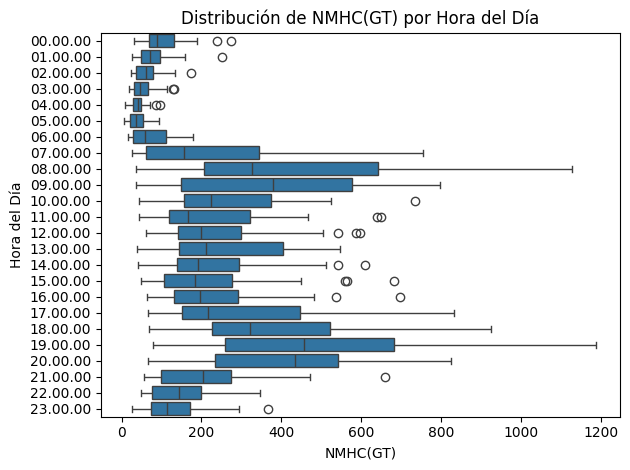

In [101]:
# crear subplots

sns.boxplot(
    data=cleaned_air_q_df,
    y='Time',   # Variable categórica
    x='NMHC(GT)',     # Variable numérica

)
plt.title('Distribución de NMHC(GT) por Hora del Día')
plt.xlabel('NMHC(GT)')
plt.ylabel('Hora del Día')

plt.tight_layout()
plt.show()

####Análisis Bivariado: Numérica/Numérica con Categorización
Se observa que en las primeras horas del día los valores de las variables graficadas son menores y nuevamente los valores altos están alrededor de las 8 y las 19 horas.

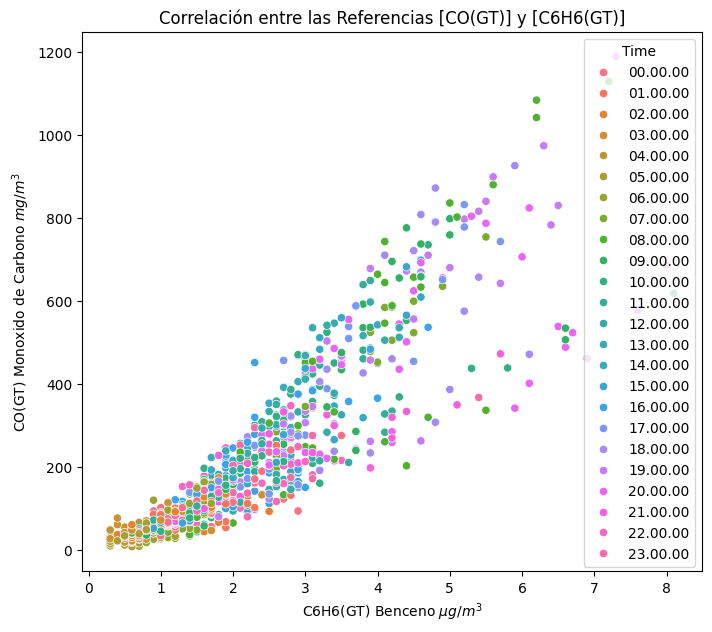

In [102]:
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=cleaned_air_q_df,x='CO(GT)',y='NMHC(GT)',hue='Time'
)

plt.title('Correlación entre las Referencias [CO(GT)] y [C6H6(GT)]')
plt.xlabel('C6H6(GT) Benceno $\\mu g /m^3$')
plt.ylabel('CO(GT) Monoxido de Carbono $mg/m^3$')

# Mostrar gráfico
plt.show()

# 5. Análisis multivariado
Realiza análisis considerando múltiples variables.

Incluye: Mapa de Calor - Correlación entre variables

####Interpretación de la correlación de variables.
El mapa de calor muestra una estrecha relación en casi todas las variables, siendo ellas de referencia, con sufijo (GT), y de respuesta de los sensores en evaluación para calibración. Todas las correlaciones están por encima del +0.60 con excepción de dos casos:
- Los registros del sensor de óxidos de nitrógeno [PT08.S3(NOx)] tiene un comportamiento diferente, con ninguna relación con alguna de las otras variables.
- Los valores arrojados por el sensor de bióxido de nitrógeno [PT08.S4(NO2)] tienen muy baja correlación con los valores de los dos dispositivos de referencia para oxidos de nitrógeno, [NOx(GT)] y [NO2(GT)]

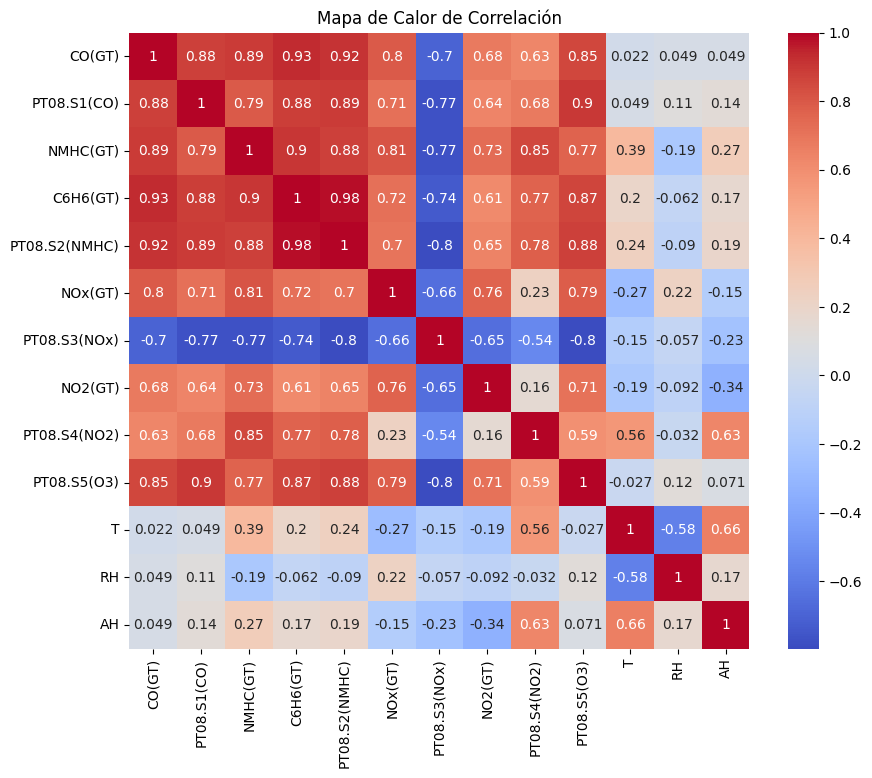

In [103]:

# Creación de la matriz de correlación.
correlation_matrix = cleaned_air_q_df[numeric_columns].corr(numeric_only=True)
plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlación')
plt.show()

### Determinación de Segmentos con K-Means

Para determinar los segmentos, seguiremos estos pasos:

1.  **Selección de Características**: Elegiremos las columnas numéricas que son relevantes para la agrupación.
2.  **Manejo de Valores Faltantes**: Imputaremos o eliminaremos las filas/columnas con valores nulos, ya que la mayoría de los algoritmos de segmentación no los manejan directamente.
3.  **Escalado de Datos**: Los algoritmos de segmentación basados en distancia (como K-Means) son sensibles a la escala de las características. Es necesario escalar los datos para dar la misma importancia a todas las variables.
4.  **Aplicación de K-Means**: Ejecutaremos el algoritmo K-Means. (INRIA, 2026)


#### Interpretación de los Segmentos

Se realizó la reducción de los datos por requerimiento del proceso de K-Means, se escalaron las variables para estandarizar su importancia y se aplicó el método de segmentacion `sklearn.cluster.KMeans`. Se formaron tres segmentos con `k=3`


In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- Selección de características y manejo de valores faltantes
# Seleccionamos las columnas numéricas y eliminamos las filas con NaN para este ejemplo.
# Nota: NMHC(GT) tiene muchos valores faltantes, lo que puede limitar su utilidad en la segmentación.
# Se podría considerar una imputación más sofisticada si se desea retener esas filas.
clustering_data = cleaned_air_q_df[numeric_columns].dropna()

print_bold("Dimensiones del dataset después de eliminar filas con NaN para segmentar:")
print(clustering_data.shape)

# --- Escalado de datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)
scaled_df = pd.DataFrame(scaled_data, columns=clustering_data.columns)

# --- Aplicación de K-Means
# Para determinar el número óptimo de clusters (k), se suele usar el método del codo.
# Por simplicidad, elegiremos un k=3.
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(scaled_data)

# Añadir las etiquetas de cluster al DataFrame original (después de descartar NaNs)
clustering_data['Cluster'] = kmeans.labels_

print_bold(f"Conteo de observaciones por segmento (K-Means con k={k}):")
print(clustering_data['Cluster'].value_counts())


Dimensiones del dataset después de eliminar filas con NaN para segmentar:
(827, 13)

Conteo de observaciones por segmento (K-Means con k=3):
Cluster
2    345
0    319
1    163
Name: count, dtype: int64


####Interpretación de los Valores Promedio por Segmento.
Los promedios de valores muestran una segmentacion coherente porque son distintas y ordenadas para los diferentes segementos (clusters); con excepción del sensor de óxidos de nitrógeno [PT08.S3(NOx)], los promedios van de menos a mas según el segmento  en el siguiente orden[0,2,1].

In [105]:
#  Observación de las características promedio de cada cluster
print(clustering_data.groupby('Cluster')[numeric_columns].mean())

           CO(GT)  PT08.S1(CO)    NMHC(GT)   C6H6(GT)  PT08.S2(NMHC)  \
Cluster                                                                
0        1.110972   981.489028   70.244514   4.042633     701.952978   
1        4.593865  1560.546012  560.214724  22.572393    1360.325153   
2        2.444058  1250.585507  224.159420  11.416812    1024.121739   

            NOx(GT)  PT08.S3(NOx)     NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
Cluster                                                                    
0         71.802508   1227.454545   71.178683   1320.576803   681.761755   
1        267.852761    655.104294  139.263804   2059.503067  1611.601227   
2        151.046377    864.657971  108.721739   1642.753623  1115.113043   

                 T         RH        AH  
Cluster                                  
0        12.884953  52.667398  0.755685  
1        17.840491  47.460123  0.927257  
2        17.055362  46.456812  0.857205  


### Comprobación de Correlación entre Segmentos y la Hora del Día

La gráfica de líneas muestra claramente cual segmento predomina en cada hora del día y vemos que el de valores menores predomina de las 23 a las 7 horas, el de valores intermedios de las 10 a las 18 horas y luego de las 21 a las  22 horas. Finalmente el de valores altos domina las horas 8,9,19 y 20.

<Figure size 1000x600 with 0 Axes>

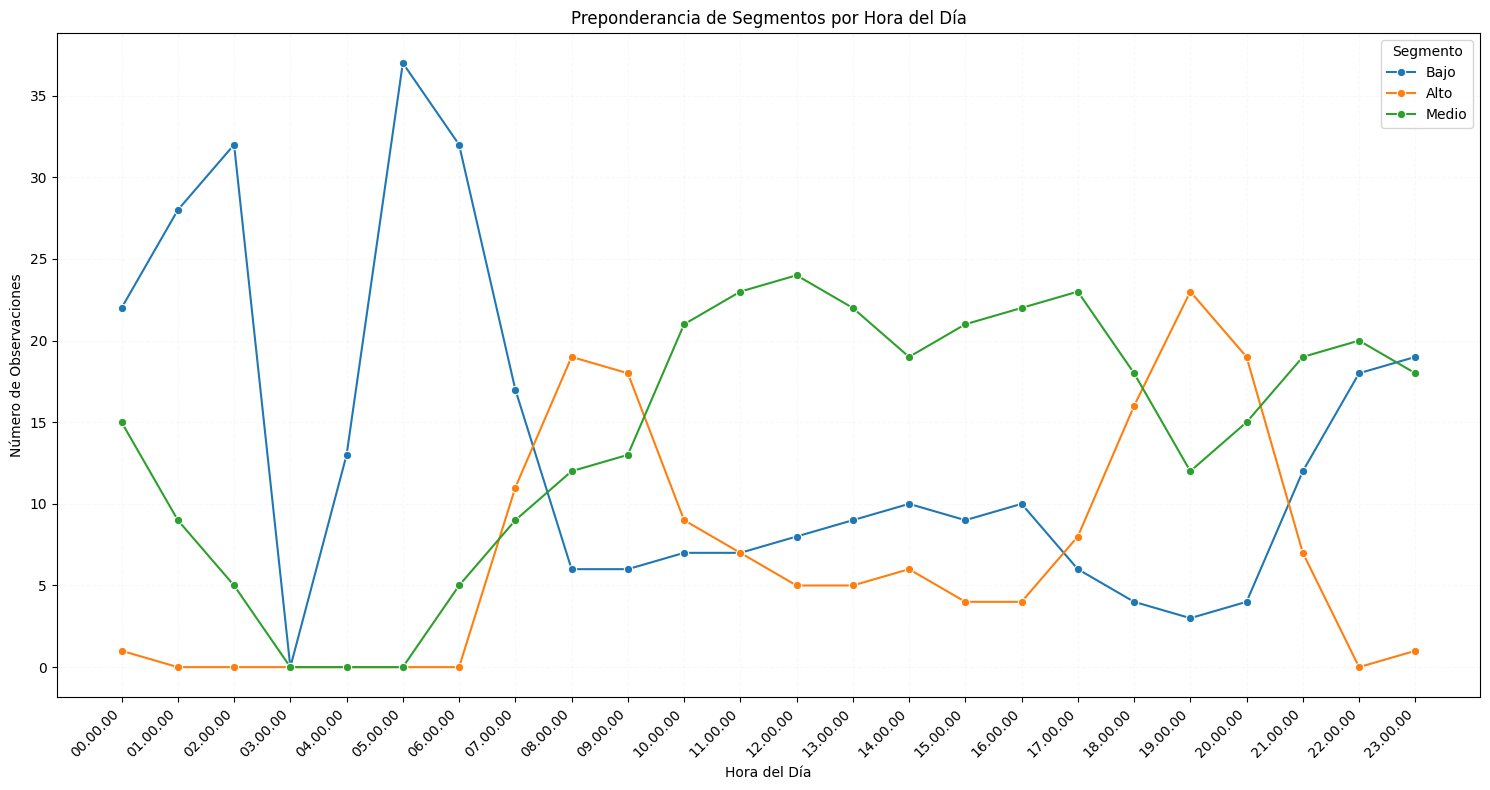

In [106]:
plt.figure(figsize=(10, 6))

# Agregar la columa Time
clustering_data['Time'] = cleaned_air_q_df.loc[clustering_data.index, 'Time']

# Contar la cantidad de observaciones de cada cluster por cada hora del día
cluster_time_distribution = clustering_data.groupby(['Time', 'Cluster'], observed=False).size().unstack(fill_value=0)

# Reshape data for line plot
cluster_time_melted = cluster_time_distribution.reset_index().melt(id_vars=['Time'], var_name='Cluster', value_name='Num_Observaciones')

# Mapear los nombres de los clusters a etiquetas más descriptivas
cluster_labels = {0: 'Bajo', 2: 'Medio', 1: 'Alto'} # Based on average values observed earlier
cluster_time_melted['Cluster_Label'] = cluster_time_melted['Cluster'].map(cluster_labels)

# Visualizar la distribución de los clusters a lo largo del día con líneas
plt.figure(figsize=(15, 8))
sns.lineplot(data=cluster_time_melted, x='Time', y='Num_Observaciones', hue='Cluster_Label', marker='o')
plt.title('Preponderancia de Segmentos por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Número de Observaciones')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segmento')
plt.grid(True, linestyle='--', alpha=0.07)
plt.tight_layout()
plt.show()

# 6. Identificación de patrones
Con base en el análisis realizado, responde:

¿Qué **patrones importantes** encontraste?

¿Existen **relaciones entre variables**?

¿Se observan **clusters naturale**s?

¿Existen **outliers**?

¿Qué variables parecen ser más relevantes?


##Respuestas a la sección Identificación de patrones.
**Patrones importantes:**

- Los hidrocarburos no metánicos como indicador de contaminación mostraron sensibilidad a la hora del día, permitiendo identificar los horarios de baja concentración entre las 22 y las 6 horas, los de mayor concentración entre las 7 y las 19, con picos prominentes alrededor de las 8 y de las 19 horas.
- Los sensores de oxidos de nitrógeno no presentan una correlación importante con sus valores asociados de referencia y en el caso del sensor [PT08.S3(NOx)] con ninguna de las otras variables.
- Las variables con el sufijo (GT) son los valores de referencia registrados en una estación de registro de contaminantes, por lo que cobran relevancia como valores confiables.

**Relaciones entre Variables**
El mapa de calor mostró que todas las variables numéricas tienen una alta correlación entre sí, con la excepción de los valores de dos sensores. Asimismo el comportamiento conjunto de las variables numéricas son sensibles a la hora del día.

**Clusters naturales**

- Finalmente mediante la segmentación y su análisis de correlación con la hora del día se pudo concluir que existe una comportamiento definido y horas del día preponderantes para cada segmento.

**Valores Atípicos**

- Durante el análisis realizado se observaron valores atípicos en los registros de referencia de benceno y monóxido de carbono, asi como en los hidrocarburos no metánicos.

# Referencias
Bruce, P., Bruce, A., & Gedeck, P. (2020). Practical Statistics for Data Scientists (Second Edition). O’Reilly Media, Inc. (Obra original publicada en Nicole Tache)

INRIA. (2026). KMeans. Scikit-Learn. https://scikit-learn/stable/modules/generated/sklearn.cluster.KMeans.html
